## Codigo optimizado para aprovechar los nucleos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import display, HTML
import time
import pickle
import os
import sys
import csv
from numba import njit, prange

In [4]:
# --- Funciones optimizadas con Numba ---
@njit(parallel=True, fastmath=True)
def actualizar_campos(u_old, v_old, p_old, T_old, u_star, v_star, p_star, T_star,
                      Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny):
    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_u_x = u_old[i, j] * (u_old[i, j + 1] - u_old[i, j - 1]) / (2 * dx_star)
            conv_u_y = v_old[i, j] * (u_old[i + 1, j] - u_old[i - 1, j]) / (2 * dy_star)
            diff_u_x = (u_old[i, j + 1] - 2 * u_old[i, j] + u_old[i, j - 1]) / dx_star**2
            diff_u_y = (u_old[i + 1, j] - 2 * u_old[i, j] + u_old[i - 1, j]) / dy_star**2
            u_star[i, j] += dt_star * (-conv_u_x - conv_u_y + (1 / Re) * (diff_u_x + diff_u_y))

            conv_v_x = u_old[i, j] * (v_old[i, j + 1] - v_old[i, j - 1]) / (2 * dx_star)
            conv_v_y = v_old[i, j] * (v_old[i + 1, j] - v_old[i - 1, j]) / (2 * dy_star)
            diff_v_x = (v_old[i, j + 1] - 2 * v_old[i, j] + v_old[i, j - 1]) / dx_star**2
            diff_v_y = (v_old[i + 1, j] - 2 * v_old[i, j] + v_old[i - 1, j]) / dy_star**2
            grad_p_y = (p_old[i + 1, j] - p_old[i - 1, j]) / (2 * dy_star)
            v_star[i, j] += dt_star * (-conv_v_x - conv_v_y - Eu * grad_p_y + (1 / Re) * (diff_v_x + diff_v_y))

    for _ in range(20):
        for i in prange(1, ny - 1):
            for j in prange(1, nx - 1):
                div = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star) + \
                      (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
                p_star[i, j] = 0.25 * (p_old[i + 1, j] + p_old[i - 1, j] +
                                       p_old[i, j + 1] + p_old[i, j - 1] -
                                       (dx_star * dy_star) / (2 * (dx_star**2 + dy_star**2)) * div)

    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            u_star[i, j] -= dt_star * Eu * (p_star[i, j + 1] - p_star[i, j - 1]) / (2 * dx_star)
            v_star[i, j] -= dt_star * Eu * (p_star[i + 1, j] - p_star[i - 1, j]) / (2 * dy_star)

    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_T_x = u_star[i, j] * (T_old[i, j + 1] - T_old[i, j - 1]) / (2 * dx_star)
            conv_T_y = v_star[i, j] * (T_old[i + 1, j] - T_old[i - 1, j]) / (2 * dy_star)
            diff_T_x = (T_old[i, j + 1] - 2 * T_old[i, j] + T_old[i, j - 1]) / dx_star**2
            diff_T_y = (T_old[i + 1, j] - 2 * T_old[i, j] + T_old[i - 1, j]) / dy_star**2
            Sxx = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star)
            Syy = (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
            Sxy = 0.5 * ((u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star) +
                         (v_star[i, j + 1] - v_star[i, j - 1]) / (2 * dx_star))
            viscous_heating = (Ec / Re) * (2 * (Sxx**2 + Syy**2) + 4 * Sxy**2)
            T_star[i, j] += dt_star * (-conv_T_x - conv_T_y +
                                       (1 / (Re * Pr)) * (diff_T_x + diff_T_y) +
                                       viscous_heating)

    tau = np.empty((ny, nx))
    for i in prange(1, ny - 1):
        for j in prange(nx):
            tau[i, j] = (u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star)

    return tau

# --- Simulación principal ---
def run_simulation(nx=50, ny=50):
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    dx_star = 1.0 / (nx - 1)
    dy_star = 1.0 / (ny - 1)
    CFL_target = 0.008
    dt_cfl = CFL_target * dx_star
    dt_max = 5e-7 if nx >= 800 else 1e-5
    dt_star = min(dt_cfl, dt_max)
    nt = max(1100, int(np.ceil(1.0 / dt_star)))
    dt_star = 1.0 / nt

    u_star = np.full((ny, nx), 1.0)
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.zeros((ny, nx))

    u_star[0, :] = -0.5
    u_star[-1, :] = 1.0
    T_star[0, :] = 0.0
    T_star[-1, :] = 0.0

    u_old = u_star.copy()
    v_old = v_star.copy()
    p_old = p_star.copy()
    T_old = T_star.copy()

    u_history, v_history, p_history, T_history, tau_history = [], [], [], [], []

    for n in range(nt):
        u_old[:, :] = u_star
        v_old[:, :] = v_star
        p_old[:, :] = p_star
        T_old[:, :] = T_star

        tau = actualizar_campos(u_old, v_old, p_old, T_old,
                                u_star, v_star, p_star, T_star,
                                Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny)

        # Condiciones de frontera
        v_star[:, -1] = 0
        u_star[-1, :] = 1.0
        u_star[0, :] = -0.5
        v_star[0, :] = v_star[-1, :] = 0
        u_star[:, -1] = u_star[:, -2]
        p_star[:, 0] = p_star[:, 1]
        p_star[:, -1] = p_star[:, -2]
        p_star[0, :] = p_star[1, :]
        p_star[-1, :] = p_star[-2, :]

        if n % 10 == 0:
            print(f"\rSimulaci\u00f3n en progreso: paso {n}/{nt}", end="")
            sys.stdout.flush()
            u_history.append(u_star.copy())
            v_history.append(v_star.copy())
            p_history.append(p_star.copy())
            T_history.append(T_star.copy())
            tau_history.append(tau.copy())

    print("\rSimulaci\u00f3n finalizada.                      ")
    return {
        "u_history": u_history,
        "v_history": v_history,
        "p_history": p_history,
        "T_history": T_history,
        "tau_history": tau_history,
        "params": {"nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt},
        "X_star": np.linspace(0, 1.0, nx),
        "Y_star": np.linspace(0, 1.0, ny),
    }


In [5]:
resoluciones = [(25,25), (50, 50), (100, 100)]
carpeta_salida = 'analisis_resoluciones'

if not os.path.exists(carpeta_salida):
    os.makedirs(carpeta_salida)

for nx, ny in resoluciones:
    print(f"\n--- Ejecutando simulación {nx}x{ny} ---")
    sim = run_simulation(nx, ny)
    nombre = f"{nx}x{ny}.pkl"
    ruta = os.path.join(carpeta_salida, nombre)
    with open(ruta, 'wb') as f:
        pickle.dump(sim, f)
    print(f"✅ Simulación guardada: {ruta}")



--- Ejecutando simulación 25x25 ---
Simulación finalizada.                      
✅ Simulación guardada: analisis_resoluciones/25x25.pkl

--- Ejecutando simulación 50x50 ---
Simulación finalizada.                      
✅ Simulación guardada: analisis_resoluciones/50x50.pkl

--- Ejecutando simulación 100x100 ---
Simulación finalizada.                      
✅ Simulación guardada: analisis_resoluciones/100x100.pkl


In [6]:
resoluciones = [(200, 200), (400, 400), (800, 800)]
carpeta_salida = 'analisis_resoluciones'

if not os.path.exists(carpeta_salida):
    os.makedirs(carpeta_salida)

for nx, ny in resoluciones:
    print(f"\n--- Ejecutando simulación {nx}x{ny} ---")
    sim = run_simulation(nx, ny)
    nombre = f"{nx}x{ny}.pkl"
    ruta = os.path.join(carpeta_salida, nombre)
    with open(ruta, 'wb') as f:
        pickle.dump(sim, f)
    print(f"✅ Simulación guardada: {ruta}")



--- Ejecutando simulación 200x200 ---
Simulación finalizada.                      
✅ Simulación guardada: analisis_resoluciones/200x200.pkl

--- Ejecutando simulación 400x400 ---
Simulación en progreso: paso 35540/100000

: 

In [ ]:
import time

nx, ny = 1600, 1600
carpeta = 'simulacion_alta_resolucion'

if not os.path.exists(carpeta):
    os.makedirs(carpeta)

print(f"\n🚀 Iniciando simulación de alta resolución {nx}x{ny}...")
t0 = time.time()
sim = run_simulation(nx, ny)
t1 = time.time()
print(f"🕒 Tiempo de ejecución: {t1 - t0:.2f} segundos")

archivo = os.path.join(carpeta, f"{nx}x{ny}.pkl")
with open(archivo, 'wb') as f:
    pickle.dump(sim, f)
print(f"✅ Simulación de alta resolución guardada: {archivo}")


In [2]:

@njit(parallel=True, fastmath=True)
def actualizar_campos(u_old, v_old, p_old, T_old, u_star, v_star, p_star, T_star,
                      Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny):

    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_u_x = u_old[i, j] * (u_old[i, j + 1] - u_old[i, j - 1]) / (2 * dx_star)
            conv_u_y = v_old[i, j] * (u_old[i + 1, j] - u_old[i - 1, j]) / (2 * dy_star)
            diff_u_x = (u_old[i, j + 1] - 2 * u_old[i, j] + u_old[i, j - 1]) / dx_star**2
            diff_u_y = (u_old[i + 1, j] - 2 * u_old[i, j] + u_old[i - 1, j]) / dy_star**2
            u_star[i, j] += dt_star * (-conv_u_x - conv_u_y + (1 / Re) * (diff_u_x + diff_u_y))

            conv_v_x = u_old[i, j] * (v_old[i, j + 1] - v_old[i, j - 1]) / (2 * dx_star)
            conv_v_y = v_old[i, j] * (v_old[i + 1, j] - v_old[i - 1, j]) / (2 * dy_star)
            diff_v_x = (v_old[i, j + 1] - 2 * v_old[i, j] + v_old[i, j - 1]) / dx_star**2
            diff_v_y = (v_old[i + 1, j] - 2 * v_old[i, j] + v_old[i - 1, j]) / dy_star**2
            grad_p_y = (p_old[i + 1, j] - p_old[i - 1, j]) / (2 * dy_star)
            v_star[i, j] += dt_star * (-conv_v_x - conv_v_y - Eu * grad_p_y + (1 / Re) * (diff_v_x + diff_v_y))

    for _ in range(20):
        for i in prange(1, ny - 1):
            for j in prange(1, nx - 1):
                div = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star) + \
                      (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
                p_star[i, j] = 0.25 * (p_old[i + 1, j] + p_old[i - 1, j] + p_old[i, j + 1] + p_old[i, j - 1] -
                                       (dx_star * dy_star) / (2 * (dx_star**2 + dy_star**2)) * div)

    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            u_star[i, j] -= dt_star * Eu * (p_star[i, j + 1] - p_star[i, j - 1]) / (2 * dx_star)
            v_star[i, j] -= dt_star * Eu * (p_star[i + 1, j] - p_star[i - 1, j]) / (2 * dy_star)

    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_T_x = u_star[i, j] * (T_old[i, j + 1] - T_old[i, j - 1]) / (2 * dx_star)
            conv_T_y = v_star[i, j] * (T_old[i + 1, j] - T_old[i - 1, j]) / (2 * dy_star)
            diff_T_x = (T_old[i, j + 1] - 2 * T_old[i, j] + T_old[i, j - 1]) / dx_star**2
            diff_T_y = (T_old[i + 1, j] - 2 * T_old[i, j] + T_old[i - 1, j]) / dy_star**2
            Sxx = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star)
            Syy = (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
            Sxy = 0.5 * ((u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star) +
                         (v_star[i, j + 1] - v_star[i, j - 1]) / (2 * dx_star))
            viscous_heating = (Ec / Re) * (2 * (Sxx**2 + Syy**2) + 4 * Sxy**2)
            T_star[i, j] += dt_star * (-conv_T_x - conv_T_y + (1 / (Re * Pr)) * (diff_T_x + diff_T_y) + viscous_heating)

    return u_star, v_star, p_star, T_star

# --- Función principal para simulación grande ---
def run_large_simulation(nx=1600, ny=1600):
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    dx_star = 1.0 / (nx - 1)
    dy_star = 1.0 / (ny - 1)
    dt_cfl = 0.0446 * dx_star
    dt_star = min(dt_cfl, 5e-7)
    nt = max(1100, int(np.ceil(1.0 / dt_star)))
    dt_star = 1.0 / nt

    u_star = np.ones((ny, nx))
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.zeros((ny, nx))

    u_star[0, :] = -0.5
    u_star[-1, :] = 1.0

    for step in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
        u_star, v_star, p_star, T_star = actualizar_campos(u_old, v_old, p_old, T_old,
                                                           u_star, v_star, p_star, T_star,
                                                           Re, Pr, Ec, Eu, dt_star,
                                                           dx_star, dy_star, nx, ny)
        if step % 50 == 0:
            print(f"\rPaso {step}/{nt}", end="")

    print("\n✅ Simulación completada")
    return {
        "u": u_star,
        "v": v_star,
        "p": p_star,
        "T": T_star,
        "params": {"nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt}
    }


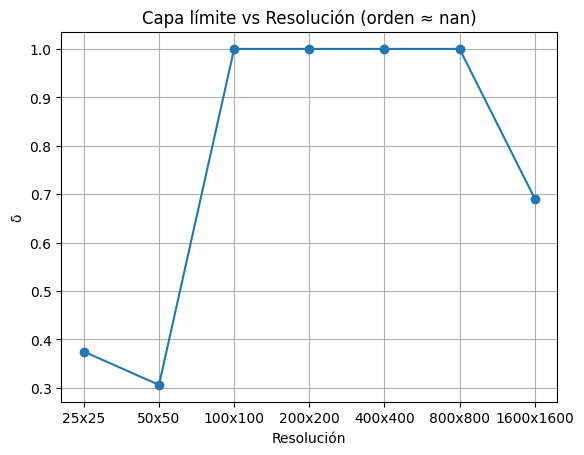

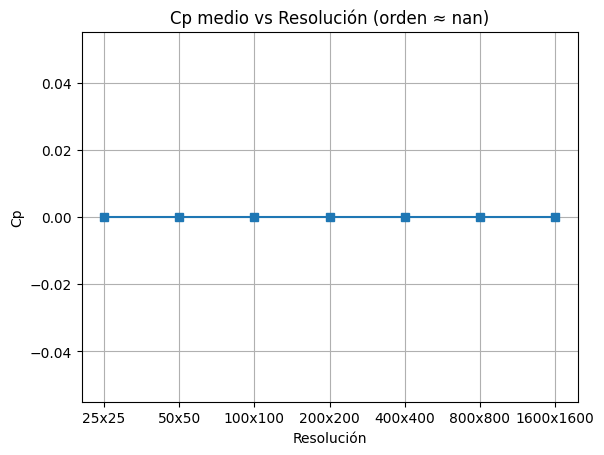

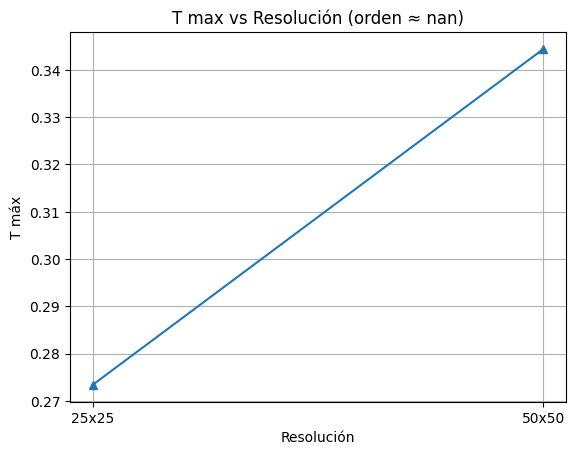

In [8]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# --- MÉTRICAS ---
def calcular_boundary_layer_thickness(u, y, u0=1.0):
    perfil = u[:, u.shape[1] // 2]
    for i in range(len(perfil)):
        if perfil[i] >= 0.99 * u0:
            return y[i]
    return y[-1]

def calcular_coeficiente_presion_medio(p):
    return np.mean(p[:, 0])  # pared izquierda

def calcular_temperatura_maxima(T):
    return np.max(T)

# --- ORDEN DE CONVERGENCIA ROBUSTO ---
def orden_convergencia(f1, f2, f3, r):
    num = f3 - f2
    den = f2 - f1
    if den == 0 or num == 0 or (num / den) <= 0:
        return np.nan
    return np.log(num / den) / np.log(r)

# --- ANÁLISIS DE CONVERGENCIA ---
def representar_convergencia(res_labels, delta_vals, cp_vals, Tmax_vals):
    r = 2
    if len(delta_vals) >= 3:
        p_delta = orden_convergencia(delta_vals[-3], delta_vals[-2], delta_vals[-1], r)
        p_cp = orden_convergencia(cp_vals[-3], cp_vals[-2], cp_vals[-1], r)
        p_T = orden_convergencia(Tmax_vals[-3], Tmax_vals[-2], Tmax_vals[-1], r)
    else:
        p_delta = p_cp = p_T = np.nan

    plt.figure()
    plt.plot(res_labels, delta_vals, marker='o')
    plt.title(f'Capa límite vs Resolución (orden ≈ {p_delta:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('δ')
    plt.grid()

    plt.figure()
    plt.plot(res_labels, cp_vals, marker='s')
    plt.title(f'Cp medio vs Resolución (orden ≈ {p_cp:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('Cp')
    plt.grid()

    plt.figure()
    plt.plot(res_labels, Tmax_vals, marker='^')
    plt.title(f'T max vs Resolución (orden ≈ {p_T:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('T máx')
    plt.grid()

    plt.show()

# --- CARGA Y PROCESAMIENTO ---
carpeta = 'sim_datos'
resoluciones = [(25, 25), (50, 50), (100, 100), (200, 200), (400, 400), (800, 800), (1600, 1600)]

delta_vals, cp_vals, Tmax_vals, labels = [], [], [], []

for nx, ny in resoluciones:
    archivo = os.path.join(carpeta, f"{nx}x{ny}.pkl")
    if not os.path.exists(archivo):
        print(f"❌ Archivo no encontrado: {archivo}")
        continue

    with open(archivo, 'rb') as f:
        sim = pickle.load(f)

    try:
        u = sim["u_history"][-1]
        p = sim["p_history"][-1]
        T = sim["T_history"][-1]
        Y = sim["Y_star"]
        y = Y[:, 0] if Y.ndim == 2 else Y

        delta_vals.append(calcular_boundary_layer_thickness(u, y))
        cp_vals.append(calcular_coeficiente_presion_medio(p))
        Tmax_vals.append(calcular_temperatura_maxima(T))
        labels.append(f"{nx}x{ny}")
    except Exception as e:
        print(f"⚠️ Error al procesar {archivo}: {e}")

# --- GRÁFICAS ---
representar_convergencia(labels, delta_vals, cp_vals, Tmax_vals)


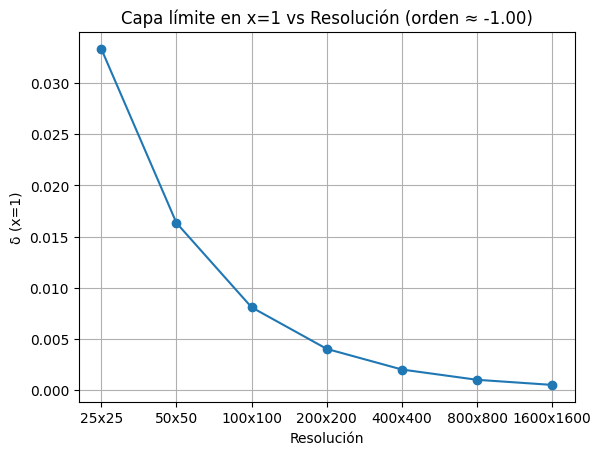

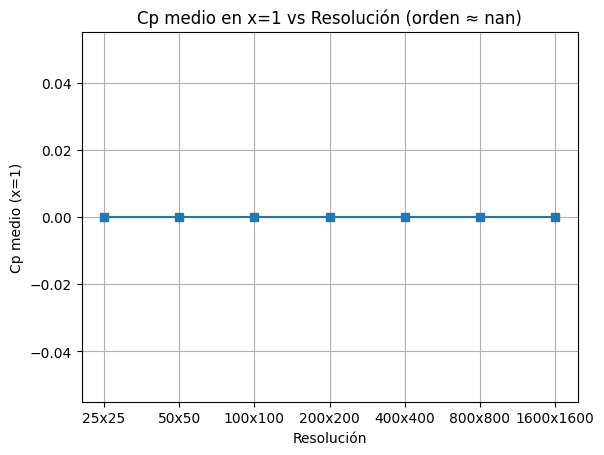

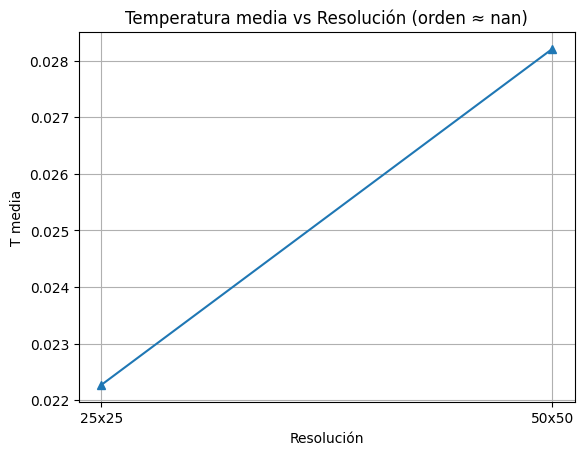

In [11]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# --- MÉTRICAS ADAPTADAS ---

def calcular_boundary_layer_thickness_veloc(u, v, X_star, Y_star, vel_level=0.9):
    """
    Interpola la altura en x=1 donde la magnitud de la velocidad cruza vel_level.
    """
    x_index = np.argmin(np.abs(X_star[0] - 1.0))
    y = Y_star[:, x_index]
    u_col = np.sqrt(u[:, x_index]**2 + v[:, x_index]**2)

    for i in range(len(u_col) - 1):
        if (u_col[i] < vel_level and u_col[i+1] > vel_level) or (u_col[i] > vel_level and u_col[i+1] < vel_level):
            dy = y[i+1] - y[i]
            du = u_col[i+1] - u_col[i]
            return y[i] + (vel_level - u_col[i]) * dy / du
    return y[-1]  # no se cruzó

def calcular_coeficiente_presion_derecha(p, X_star):
    j = np.argmin(np.abs(X_star[-1] - 1.0))
    return np.mean(p[:, j])

def calcular_temperatura_media(T):
    return np.mean(T)

def orden_convergencia(f1, f2, f3, r):
    num = f3 - f2
    den = f2 - f1
    if den == 0 or num == 0 or (num / den) <= 0:
        return np.nan
    return np.log(num / den) / np.log(r)

# --- GRÁFICAS ---
def representar_convergencia(res_labels, delta_vals, cp_vals, Tavg_vals):
    r = 2
    if len(delta_vals) >= 3:
        p_delta = orden_convergencia(delta_vals[-3], delta_vals[-2], delta_vals[-1], r)
        p_cp = orden_convergencia(cp_vals[-3], cp_vals[-2], cp_vals[-1], r)
        p_T = orden_convergencia(Tavg_vals[-3], Tavg_vals[-2], Tavg_vals[-1], r)
    else:
        p_delta = p_cp = p_T = np.nan

    plt.figure()
    plt.plot(res_labels, delta_vals, marker='o')
    plt.title(f'Capa límite en x=1 vs Resolución (orden ≈ {p_delta:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('δ (x=1)')
    plt.grid()

    plt.figure()
    plt.plot(res_labels, cp_vals, marker='s')
    plt.title(f'Cp medio en x=1 vs Resolución (orden ≈ {p_cp:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('Cp medio (x=1)')
    plt.grid()

    plt.figure()
    plt.plot(res_labels, Tavg_vals, marker='^')
    plt.title(f'Temperatura media vs Resolución (orden ≈ {p_T:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('T media')
    plt.grid()

    plt.show()

# --- CARGA Y PROCESAMIENTO ---
carpeta = 'sim_datos'
resoluciones = [(25, 25), (50, 50), (100, 100), (200, 200), (400, 400), (800, 800), (1600, 1600)]

delta_vals, cp_vals, Tavg_vals, labels = [], [], [], []

for nx, ny in resoluciones:
    archivo = os.path.join(carpeta, f"{nx}x{ny}.pkl")
    if not os.path.exists(archivo):
        print(f"❌ Archivo no encontrado: {archivo}")
        continue

    with open(archivo, 'rb') as f:
        sim = pickle.load(f)

    try:
        u = sim["u_history"][-1]
        v = sim["v_history"][-1]
        p = sim["p_history"][-1]
        T = sim["T_history"][-1]
        X_star = sim["X_star"]
        Y_star = sim["Y_star"]

        delta = calcular_boundary_layer_thickness_veloc(u, v, X_star, Y_star)
        cp = calcular_coeficiente_presion_derecha(p, X_star)
        Tavg = calcular_temperatura_media(T)

        delta_vals.append(delta)
        cp_vals.append(cp)
        Tavg_vals.append(Tavg)
        labels.append(f"{nx}x{ny}")
    except Exception as e:
        print(f"⚠️ Error al procesar {archivo}: {e}")

# --- MOSTRAR RESULTADOS ---
representar_convergencia(labels, delta_vals, cp_vals, Tavg_vals)


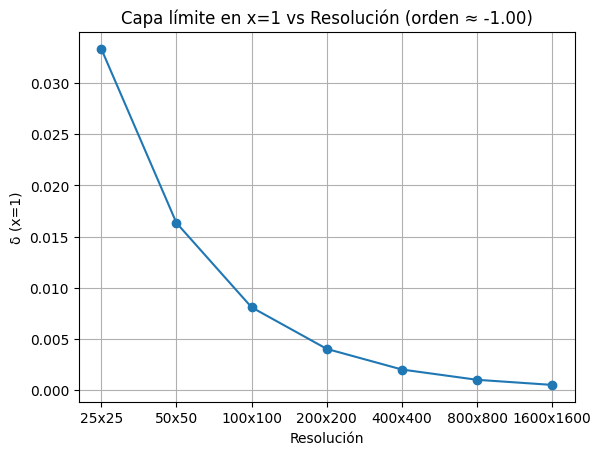

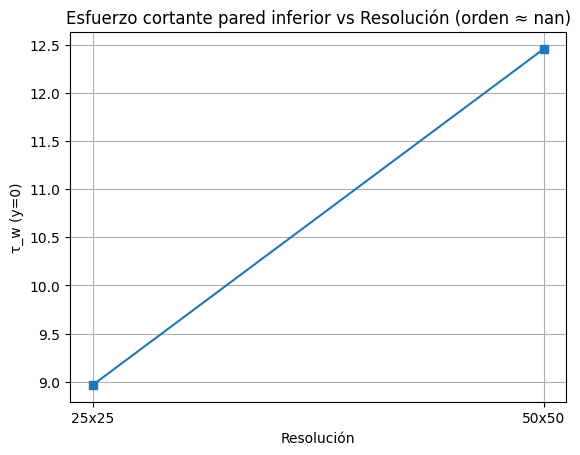

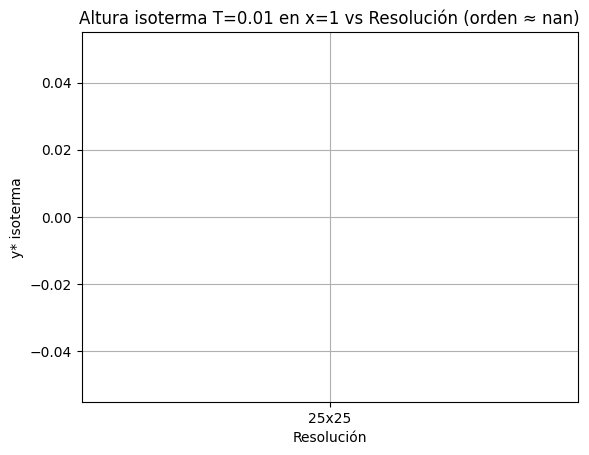

In [12]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# --- MÉTRICAS ACTUALIZADAS ---

def calcular_boundary_layer_thickness_veloc(u, v, X_star, Y_star, vel_level=0.9):
    x_index = np.argmin(np.abs(X_star[0] - 1.0))
    y = Y_star[:, x_index]
    u_col = np.sqrt(u[:, x_index]**2 + v[:, x_index]**2)
    for i in range(len(u_col) - 1):
        if (u_col[i] < vel_level and u_col[i+1] > vel_level) or (u_col[i] > vel_level and u_col[i+1] < vel_level):
            dy = y[i+1] - y[i]
            du = u_col[i+1] - u_col[i]
            return y[i] + (vel_level - u_col[i]) * dy / du
    return y[-1]

def calcular_shear_wall(tau):
    return np.mean(tau[1, :])  # esfuerzo cortante en y ≈ 0 (pared inferior)

def calcular_altura_isoterma(T, X_star, Y_star, temp_level=0.01):
    j = np.argmin(np.abs(X_star[0] - 1.0))
    T_col = T[:, j]
    y = Y_star[:, j]
    for i in range(len(T_col) - 1):
        if (T_col[i] < temp_level and T_col[i+1] > temp_level) or \
           (T_col[i] > temp_level and T_col[i+1] < temp_level):
            dy = y[i+1] - y[i]
            dT = T_col[i+1] - T_col[i]
            return y[i] + (temp_level - T_col[i]) * dy / dT
    return None

def orden_convergencia(f1, f2, f3, r):
    num = f3 - f2
    den = f2 - f1
    if den == 0 or num == 0 or (num / den) <= 0:
        return np.nan
    return np.log(num / den) / np.log(r)

# --- GRÁFICAS ---
def representar_convergencia(res_labels, delta_vals, shear_vals, isoterma_vals):
    r = 2
    if len(delta_vals) >= 3:
        p_delta = orden_convergencia(delta_vals[-3], delta_vals[-2], delta_vals[-1], r)
        p_shear = orden_convergencia(shear_vals[-3], shear_vals[-2], shear_vals[-1], r)
        p_iso = orden_convergencia(isoterma_vals[-3], isoterma_vals[-2], isoterma_vals[-1], r)
    else:
        p_delta = p_shear = p_iso = np.nan

    plt.figure()
    plt.plot(res_labels, delta_vals, marker='o')
    plt.title(f'Capa límite en x=1 vs Resolución (orden ≈ {p_delta:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('δ (x=1)')
    plt.grid()

    plt.figure()
    plt.plot(res_labels, shear_vals, marker='s')
    plt.title(f'Esfuerzo cortante pared inferior vs Resolución (orden ≈ {p_shear:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('τ_w (y=0)')
    plt.grid()

    plt.figure()
    plt.plot(res_labels, isoterma_vals, marker='^')
    plt.title(f'Altura isoterma T=0.01 en x=1 vs Resolución (orden ≈ {p_iso:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('y* isoterma')
    plt.grid()

    plt.show()

# --- CARGA Y PROCESAMIENTO ---
carpeta = 'sim_datos'
resoluciones = [(25, 25), (50, 50), (100, 100), (200, 200), (400, 400), (800, 800), (1600, 1600)]

delta_vals, shear_vals, isoterma_vals, labels = [], [], [], []

for nx, ny in resoluciones:
    archivo = os.path.join(carpeta, f"{nx}x{ny}.pkl")
    if not os.path.exists(archivo):
        print(f"❌ Archivo no encontrado: {archivo}")
        continue

    with open(archivo, 'rb') as f:
        sim = pickle.load(f)

    try:
        u = sim["u_history"][-1]
        v = sim["v_history"][-1]
        p = sim["p_history"][-1]
        T = sim["T_history"][-1]
        tau = sim["tau_history"][-1]
        X_star = sim["X_star"]
        Y_star = sim["Y_star"]

        delta = calcular_boundary_layer_thickness_veloc(u, v, X_star, Y_star)
        tau_w = calcular_shear_wall(tau)
        y_iso = calcular_altura_isoterma(T, X_star, Y_star, temp_level=0.01)

        delta_vals.append(delta)
        shear_vals.append(tau_w)
        isoterma_vals.append(y_iso if y_iso is not None else np.nan)
        labels.append(f"{nx}x{ny}")
    except Exception as e:
        print(f"⚠️ Error al procesar {archivo}: {e}")

# --- MOSTRAR RESULTADOS ---
representar_convergencia(labels, delta_vals, shear_vals, isoterma_vals)


/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1224/3232742872.py:39: RuntimeWarning: invalid value encountered in scalar divide
  cp_errs = [abs(c - cp_ref) / cp_ref for c in cp_vals[:-1]]


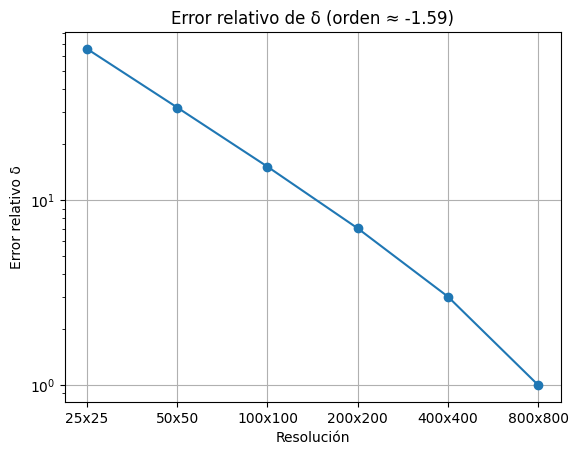

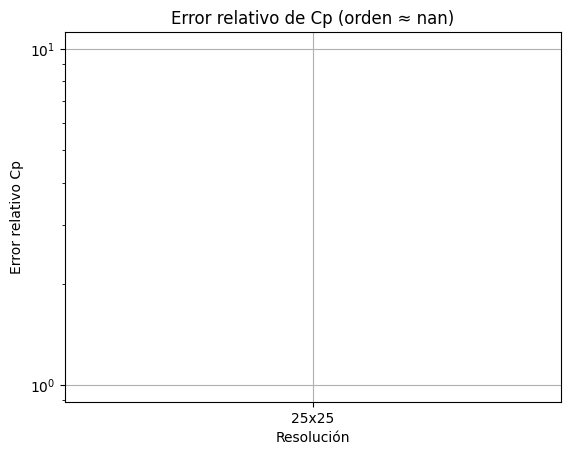

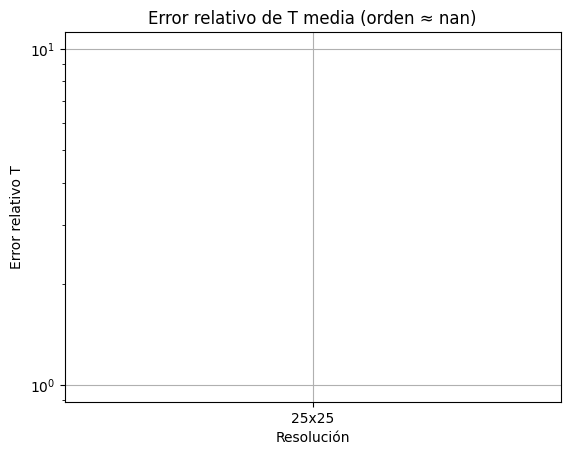

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# --- MÉTRICAS ADAPTADAS ---

def calcular_boundary_layer_thickness_veloc(u, v, X_star, Y_star, vel_level=0.9):
    x_index = np.argmin(np.abs(X_star[0] - 1.0))
    y = Y_star[:, x_index]
    u_col = np.sqrt(u[:, x_index]**2 + v[:, x_index]**2)
    for i in range(len(u_col) - 1):
        if (u_col[i] < vel_level and u_col[i+1] > vel_level) or (u_col[i] > vel_level and u_col[i+1] < vel_level):
            dy = y[i+1] - y[i]
            du = u_col[i+1] - u_col[i]
            return y[i] + (vel_level - u_col[i]) * dy / du
    return y[-1]

def calcular_coeficiente_presion_derecha(p, X_star):
    j = np.argmin(np.abs(X_star[-1] - 1.0))
    return np.mean(p[:, j])

def calcular_temperatura_media(T):
    return np.mean(T)

def orden_convergencia_error(e1, e2, r):
    if e1 == 0 or e2 == 0 or (e2 / e1) <= 0:
        return np.nan
    return np.log(e2 / e1) / np.log(r)

# --- GRÁFICAS DE ERROR ---
def representar_error_convergencia(labels, delta_vals, cp_vals, Tavg_vals):
    r = 2
    delta_ref = delta_vals[-1]
    cp_ref = cp_vals[-1]
    Tavg_ref = Tavg_vals[-1]

    delta_errs = [abs(d - delta_ref) / delta_ref for d in delta_vals[:-1]]
    cp_errs = [abs(c - cp_ref) / cp_ref for c in cp_vals[:-1]]
    Tavg_errs = [abs(t - Tavg_ref) / Tavg_ref for t in Tavg_vals[:-1]]

    labels_err = labels[:-1]

    # Orden de convergencia
    p_delta = orden_convergencia_error(delta_errs[-2], delta_errs[-1], r) if len(delta_errs) >= 2 else np.nan
    p_cp = orden_convergencia_error(cp_errs[-2], cp_errs[-1], r) if len(cp_errs) >= 2 else np.nan
    p_T = orden_convergencia_error(Tavg_errs[-2], Tavg_errs[-1], r) if len(Tavg_errs) >= 2 else np.nan

    plt.figure()
    plt.plot(labels_err, delta_errs, marker='o')
    plt.yscale('log')
    plt.title(f'Error relativo de δ (orden ≈ {p_delta:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('Error relativo δ')
    plt.grid()

    plt.figure()
    plt.plot(labels_err, cp_errs, marker='s')
    plt.yscale('log')
    plt.title(f'Error relativo de Cp (orden ≈ {p_cp:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('Error relativo Cp')
    plt.grid()

    plt.figure()
    plt.plot(labels_err, Tavg_errs, marker='^')
    plt.yscale('log')
    plt.title(f'Error relativo de T media (orden ≈ {p_T:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('Error relativo T')
    plt.grid()

    plt.show()

# --- CARGA Y PROCESAMIENTO ---
carpeta = 'sim_datos_1'
resoluciones = [(25, 25), (50, 50), (100, 100), (200, 200), (400, 400), (800, 800), (1600, 1600)]

delta_vals, cp_vals, Tavg_vals, labels = [], [], [], []

for nx, ny in resoluciones:
    archivo = os.path.join(carpeta, f"{nx}x{ny}.pkl")
    if not os.path.exists(archivo):
        print(f"❌ Archivo no encontrado: {archivo}")
        continue

    with open(archivo, 'rb') as f:
        sim = pickle.load(f)

    try:
        u = sim["u_history"][-1]
        v = sim["v_history"][-1]
        p = sim["p_history"][-1]
        T = sim["T_history"][-1]
        X_star = sim["X_star"]
        Y_star = sim["Y_star"]

        delta = calcular_boundary_layer_thickness_veloc(u, v, X_star, Y_star)
        cp = calcular_coeficiente_presion_derecha(p, X_star)
        Tavg = calcular_temperatura_media(T)

        delta_vals.append(delta)
        cp_vals.append(cp)
        Tavg_vals.append(Tavg)
        labels.append(f"{nx}x{ny}")
    except Exception as e:
        print(f"⚠️ Error al procesar {archivo}: {e}")

# --- MOSTRAR ERRORES RELATIVOS ---
representar_error_convergencia(labels, delta_vals, cp_vals, Tavg_vals)


In [ ]:
import os
import pickle
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib.pyplot as plt

def animar_resultados_linea(sim_data, vel_level=0.9, temp_level=0.01):
    X_star = sim_data["X_star"]
    Y_star = sim_data["Y_star"]
    u_hist = sim_data["u_history"]
    v_hist = sim_data["v_history"]
    p_hist = sim_data["p_history"]
    T_hist = sim_data["T_history"]
    tau_hist = sim_data["tau_history"]
    dt_star = sim_data["params"]["dt_star"]

    dt_star_visual = 50 * dt_star
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))

    text1 = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, fontsize=9, color='white',
                     bbox=dict(facecolor='black', alpha=0.5))
    text2 = ax2.text(0.02, 0.95, '', transform=ax2.transAxes, fontsize=9, color='white',
                     bbox=dict(facecolor='black', alpha=0.5))

    def interp_crossing(y, field, level):
        for i in range(len(field) - 1):
            f1, f2 = field[i], field[i+1]
            if (f1 < level and f2 > level) or (f1 > level and f2 < level):
                dy = y[i+1] - y[i]
                df = f2 - f1
                return y[i] + (level - f1) * dy / df
        return None

    def y_on_line_at_x(line_points, x_target):
        tol = 0.01
        x_vals, y_vals = line_points[:, 0], line_points[:, 1]
        close_idx = np.where(np.abs(x_vals - x_target) < tol)[0]
        if len(close_idx) == 0:
            return None
        return float(np.max(y_vals[close_idx]))

    linea_temp_plot, = ax2.plot([], [], 'k', linewidth=1.5)

    def update(frame):
        speed = np.sqrt(u_hist[frame]**2 + v_hist[frame]**2)

        for ax in [ax1, ax2, ax3, ax4]:
            while ax.collections:
                ax.collections[-1].remove()

        ax1.contourf(X_star, Y_star, speed, levels=20, cmap='jet')
        ax1.contour(X_star, Y_star, speed, levels=[vel_level], colors='k', linewidths=1.5)

        cs = ax2.contour(X_star, Y_star, T_hist[frame], levels=[temp_level], colors='k', linewidths=1.5)
        selected_line = None
        if cs.allsegs and len(cs.allsegs[0]) > 0:
            selected_line = np.concatenate(cs.allsegs[0])
            linea_temp_plot.set_data(selected_line[:, 0], selected_line[:, 1])
        else:
            linea_temp_plot.set_data([], [])

        ax2.contourf(X_star, Y_star, T_hist[frame], levels=20, cmap='jet')
        ax3.contourf(X_star, Y_star, p_hist[frame], levels=20, cmap='viridis')
        ax4.contourf(X_star, Y_star, tau_hist[frame], levels=20, cmap='coolwarm')

        t_star = frame * dt_star_visual
        ax1.set_title(f'Velocidad |u*| (t*={t_star:.2f})')
        ax2.set_title(f'Temperatura T* (t*={t_star:.2f})')
        ax3.set_title(f'Presión p* (t*={t_star:.2f})')
        ax4.set_title(f'Shear stress τ* (t*={t_star:.2f})')

        y80 = y_on_line_at_x(selected_line, 0.80) if selected_line is not None else None
        y95 = y_on_line_at_x(selected_line, 0.95) if selected_line is not None else None

        y80_str = f"{y80:.4f}" if y80 is not None else "No definido"
        y95_str = f"{y95:.4f}" if y95 is not None else "No definido"
        text2.set_text(f'Línea T* en x=0.80: {y80_str}\nLínea T* en x=0.95: {y95_str}')

        x_index = np.argmin(np.abs(X_star[0] - 1.0))
        y_col = Y_star[:, x_index]
        u_col = np.sqrt(u_hist[frame][:, x_index]**2 + v_hist[frame][:, x_index]**2)
        y_vel = interp_crossing(y_col, u_col, vel_level)
        y_vel_str = f"{y_vel:.4f}" if y_vel is not None else "No definido"
        text1.set_text(f'y* @ x=1 donde |u*|={vel_level}:\n{y_vel_str}')

        if frame == len(u_hist) - 1:
            print(f"\nt* = {t_star:.3f}")
            print(f"  |u*|={vel_level} @ x=1 → y* = {y_vel_str}")
            print(f"  Línea T* @ x=0.80 → y* = {y80_str}")
            print(f"  Línea T* @ x=0.95 → y* = {y95_str}")

        return ax1.collections + ax2.collections + ax3.collections + ax4.collections + [text1, text2, linea_temp_plot]

    # Primer fotograma
    speed = np.sqrt(u_hist[0]**2 + v_hist[0]**2)
    ax1.contourf(X_star, Y_star, speed, levels=20, cmap='jet')
    ax1.contour(X_star, Y_star, speed, levels=[vel_level], colors='k', linewidths=1.5)

    cs0 = ax2.contour(X_star, Y_star, T_hist[0], levels=[temp_level], colors='k', linewidths=1.5)
    if cs0.allsegs and len(cs0.allsegs[0]) > 0:
        selected_line0 = np.concatenate(cs0.allsegs[0])
        linea_temp_plot.set_data(selected_line0[:, 0], selected_line0[:, 1])
    else:
        linea_temp_plot.set_data([], [])

    ax2.contourf(X_star, Y_star, T_hist[0], levels=20, cmap='jet')
    ax3.contourf(X_star, Y_star, p_hist[0], levels=20, cmap='viridis')
    ax4.contourf(X_star, Y_star, tau_hist[0], levels=20, cmap='coolwarm')

    fig.suptitle(f"Simulación con resolución {X_star.shape[1]}x{Y_star.shape[0]}, CFL fija", fontsize=14)
    plt.tight_layout()

    anim = FuncAnimation(fig, update, frames=len(u_hist), interval=100, blit=False)
    return anim, fig


# Asegurar carpeta de salida
output_folder = 'opti_anim_1'
os.makedirs(output_folder, exist_ok=True)

# --- Función de animación (debe estar definida previamente) ---
# Usa aquí la función animar_resultados_linea(sim_data, ...) completa que ya tienes

# --- Procesar archivos ---
carpeta = 'sim_datos'
resoluciones = [(25, 25), (50, 50), (100, 100), (200, 200), (400, 400)]#, (800, 800), (1600, 1600)]

for nx, ny in resoluciones:
    nombre = f"{nx}x{ny}"
    archivo = os.path.join(carpeta, f"{nombre}.pkl")
    if not os.path.exists(archivo):
        print(f"❌ No se encontró: {archivo}")
        continue

    print(f"🎞️ Generando animación para {nombre}...")
    with open(archivo, 'rb') as f:
        sim = pickle.load(f)

    try:
        anim, fig = animar_resultados_linea(sim)
        salida_mp4 = os.path.join(output_folder, f"{nombre}.mp4")

        writer = FFMpegWriter(fps=10, metadata={"title": nombre})
        anim.save(salida_mp4, writer=writer)
        plt.close(fig)
        print(f"✅ Guardado: {salida_mp4}")
    except Exception as e:
        print(f"⚠️ Error al animar {nombre}: {e}")


🎞️ Generando animación para 25x25...

t* = 0.197
  |u*|=0.9 @ x=1 → y* = 0.3198
  Línea T* @ x=0.80 → y* = 0.4824
  Línea T* @ x=0.95 → y* = 0.4999
✅ Guardado: opti_anim_1/25x25.mp4
🎞️ Generando animación para 50x50...

t* = 0.199
  |u*|=0.9 @ x=1 → y* = 0.2942
  Línea T* @ x=0.80 → y* = 0.4845
  Línea T* @ x=0.95 → y* = 0.4898
✅ Guardado: opti_anim_1/50x50.mp4
🎞️ Generando animación para 100x100...

t* = 0.200
  |u*|=0.9 @ x=1 → y* = 0.2814
  Línea T* @ x=0.80 → y* = 0.4964
  Línea T* @ x=0.95 → y* = 0.5017
✅ Guardado: opti_anim_1/100x100.mp4
🎞️ Generando animación para 200x200...

t* = 0.200
  |u*|=0.9 @ x=1 → y* = 0.2749
  Línea T* @ x=0.80 → y* = 0.5028
  Línea T* @ x=0.95 → y* = 0.5085
✅ Guardado: opti_anim_1/200x200.mp4
🎞️ Generando animación para 400x400...

t* = 0.200
  |u*|=0.9 @ x=1 → y* = 0.2714
  Línea T* @ x=0.80 → y* = 0.5059
  Línea T* @ x=0.95 → y* = 0.5117
✅ Guardado: opti_anim_1/400x400.mp4
